# 03 — Storytelling : Logique du projet de bout en bout

**Projet Fil Rouge — B3 IA & Data — Ynov Aix-en-Provence 2025/2026**  
Corin Deprez & Eliott Bellais

---

Ce notebook est conçu pour l'oral. Il raconte la **logique complète du projet**, de la question initiale au résultat final, avec tous les graphiques nécessaires pour illustrer chaque étape de raisonnement.

### Plan
1. La question et le contexte
2. Les données : d'où viennent-elles ?
3. Feature engineering : qu'est-ce qu'on mesure ?
4. Pourquoi XGBoost + calibration ?
5. Comment évolue la précision dans le temps ?
6. Ce que le modèle a appris (SHAP)
7. La validation : est-ce qu'on surestime nos résultats ?
8. L'app web et la page Pro — mise en situation
9. Limites et perspectives

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

from src.features.build_features import FEATURE_COLS, TARGET_COL, SNAPSHOT_MINUTES

plt.style.use('dark_background')
GOLD = '#c89b3c'; BLUE = '#0bc4e3'; RED = '#e84057'; BG = '#070b14'; CARD = '#0d1525'

DOCS_DIR = Path('../docs/screenshots')
DOCS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_parquet('../data/processed/features.parquet')
X = df[FEATURE_COLS]; y = df[TARGET_COL]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = joblib.load('../models/xgboost_final.pkl')
base_xgb = model.calibrated_classifiers_[0].estimator

print(f'Dataset : {len(df):,} snapshots | {df["match_id"].nunique():,} matchs | {len(FEATURE_COLS)} features')
print(f'Blue win rate : {y.mean():.1%}')

Dataset : 40,475 snapshots | 9,625 matchs | 26 features
Blue win rate : 48.0%


---
## 1. La question

> *"À quelle minute une partie de League of Legends est-elle déjà jouée ?"*

League of Legends est un jeu de stratégie en temps réel à 5v5. Une partie dure en moyenne **28-35 minutes** et implique des centaines d'événements (combats, objectifs, farm). La question est : **peut-on prédire le gagnant en cours de partie**, et à partir de quand ?

**Approche :** Machine Learning supervisé — classification binaire (victoire équipe bleue = 1, défaite = 0).

---
## 2. Les données

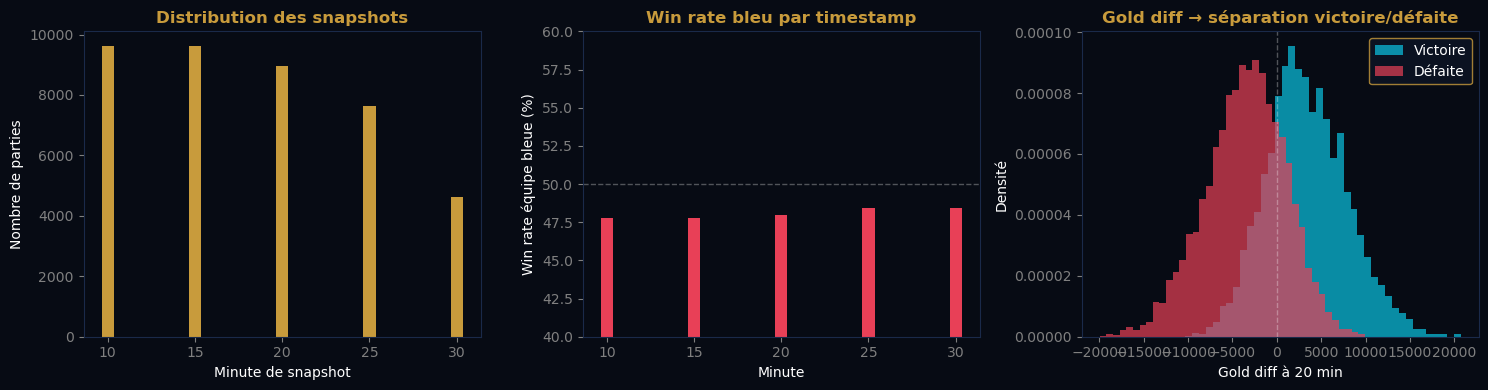

Figure 1 — Aperçu des données


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), facecolor=BG)

# Distribution des snapshots par minute
ax = axes[0]; ax.set_facecolor(BG)
counts = df['game_time_minutes'].value_counts().sort_index()
ax.bar(counts.index, counts.values, color=GOLD, edgecolor='none', width=0.7)
ax.set_xlabel('Minute de snapshot', color='white'); ax.set_ylabel('Nombre de parties', color='white')
ax.set_title('Distribution des snapshots', color=GOLD, fontweight='bold')
ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

# Win rate par minute
ax = axes[1]; ax.set_facecolor(BG)
wr = df.groupby('game_time_minutes')[TARGET_COL].mean()
ax.bar(wr.index, wr.values * 100, color=[BLUE if v > 50 else RED for v in wr.values], edgecolor='none', width=0.7)
ax.axhline(50, color='white', alpha=0.3, linestyle='--', lw=1)
ax.set_xlabel('Minute', color='white'); ax.set_ylabel('Win rate équipe bleue (%)', color='white')
ax.set_title('Win rate bleu par timestamp', color=GOLD, fontweight='bold')
ax.set_ylim(40, 60); ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

# Distribution gold diff à 20 min
ax = axes[2]; ax.set_facecolor(BG)
g20 = df[df['game_time_minutes'] == 20]['gold_diff']
ax.hist(g20[y[g20.index] == 1], bins=40, color=BLUE, alpha=0.7, label='Victoire', density=True)
ax.hist(g20[y[g20.index] == 0], bins=40, color=RED, alpha=0.7, label='Défaite', density=True)
ax.axvline(0, color='white', alpha=0.3, linestyle='--', lw=1)
ax.set_xlabel('Gold diff à 20 min', color='white'); ax.set_ylabel('Densité', color='white')
ax.set_title('Gold diff → séparation victoire/défaite', color=GOLD, fontweight='bold')
ax.legend(facecolor=CARD, edgecolor=GOLD); ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'story_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 — Aperçu des données')

---
## 3. Feature engineering — Ce qu'on mesure

**20 features**, toutes calculées comme différentiel **équipe bleue − équipe rouge** :

| Catégorie | Features | Extraction |
|-----------|----------|------------|
| Combat | kills_diff, deaths_diff, damage_diff, cc_diff | events CHAMPION_KILL + participantFrames.damageStats |
| Économie | gold_diff, cs_diff, current_gold_diff, xp_diff | participantFrames (totalGold, minions, xp) |
| Objectifs | towers_diff, dragons_diff, barons_diff, heralds_diff, inhibitors_diff, plates_diff | events BUILDING_KILL / ELITE_MONSTER_KILL / TURRET_PLATE |
| Vision | wards_diff | events WARD_PLACED |
| Momentum | kills_last_3min, first_blood, dragon_soul, level_diff | dérivés |
| Contexte | game_time_minutes | frame index |

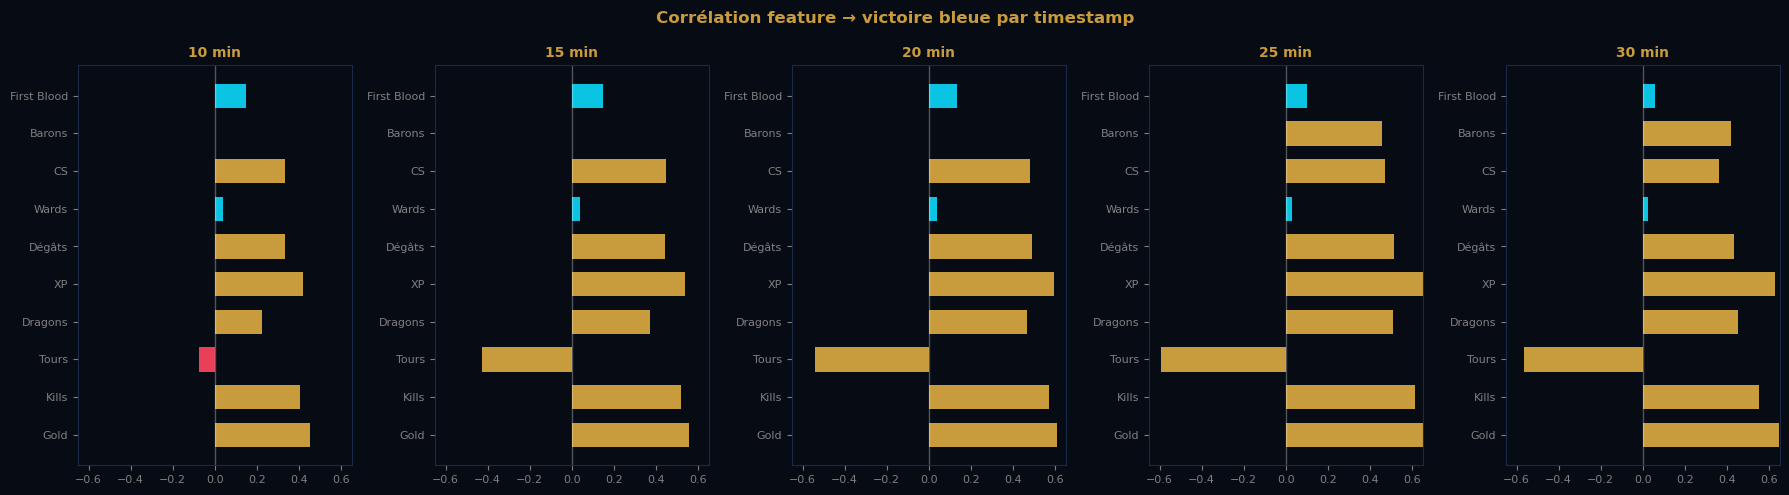

Figure 2 — Corrélations features/victoire


In [3]:
# Corrélation des features avec la victoire, par timestamp
fig, axes = plt.subplots(1, len(SNAPSHOT_MINUTES), figsize=(18, 5), facecolor=BG)

key_feats = ['gold_diff', 'kills_diff', 'towers_diff', 'dragons_diff', 'xp_diff', 
             'damage_diff', 'wards_diff', 'cs_diff', 'barons_diff', 'first_blood']
feat_labels = ['Gold', 'Kills', 'Tours', 'Dragons', 'XP', 'Dégâts', 'Wards', 'CS', 'Barons', 'First Blood']

for i, minute in enumerate(SNAPSHOT_MINUTES):
    ax = axes[i]; ax.set_facecolor(BG)
    sub = df[df['game_time_minutes'] == minute]
    corrs = [sub[f].corr(sub[TARGET_COL]) for f in key_feats]
    colors = [GOLD if abs(c) > 0.2 else BLUE if c > 0 else RED for c in corrs]
    ax.barh(feat_labels, corrs, color=colors, edgecolor='none', height=0.65)
    ax.axvline(0, color='white', alpha=0.3, lw=1)
    ax.set_title(f'{minute} min', color=GOLD, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8, colors='gray')
    ax.set_xlim(-0.65, 0.65)
    for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

plt.suptitle('Corrélation feature → victoire bleue par timestamp', color=GOLD, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'story_feature_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 — Corrélations features/victoire')

---
## 4. Pourquoi XGBoost + Platt calibration ?

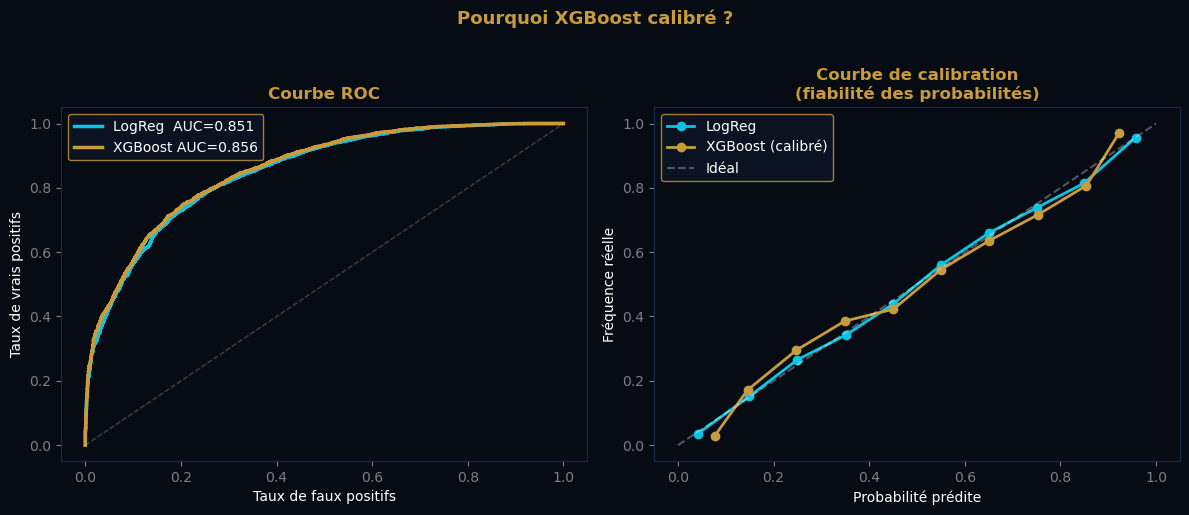

Figure 3 — Comparaison modèles
  LogReg  : accuracy=0.766 log-loss=0.474
  XGBoost : accuracy=0.772 log-loss=0.474


In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import roc_curve, log_loss, accuracy_score
import xgboost as xgb_lib

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_proba = lr.predict_proba(X_test_sc)[:, 1]

xgb_proba = model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor=BG)

# ROC
ax = axes[0]; ax.set_facecolor(BG)
for name, proba, color in [
    (f'LogReg  AUC={roc_auc_score(y_test, lr_proba):.3f}', lr_proba, BLUE),
    (f'XGBoost AUC={roc_auc_score(y_test, xgb_proba):.3f}', xgb_proba, GOLD),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=name, color=color, lw=2.5)
ax.plot([0,1],[0,1],'--',color='white',alpha=0.2,lw=1)
ax.fill_between([0,1],[0,1],[0,1],alpha=0.03,color='white')
ax.set_xlabel('Taux de faux positifs', color='white'); ax.set_ylabel('Taux de vrais positifs', color='white')
ax.set_title('Courbe ROC', color=GOLD, fontweight='bold')
ax.legend(facecolor=CARD, edgecolor=GOLD, fontsize=10); ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

# Calibration
ax = axes[1]; ax.set_facecolor(BG)
for name, proba, color in [
    ('LogReg', lr_proba, BLUE), ('XGBoost (calibré)', xgb_proba, GOLD)
]:
    fp, mp = calibration_curve(y_test, proba, n_bins=10)
    ax.plot(mp, fp, marker='o', label=name, color=color, lw=2)
ax.plot([0,1],[0,1],'--',color='white',alpha=0.3,label='Idéal')
ax.set_xlabel('Probabilité prédite', color='white'); ax.set_ylabel('Fréquence réelle', color='white')
ax.set_title('Courbe de calibration\n(fiabilité des probabilités)', color=GOLD, fontweight='bold')
ax.legend(facecolor=CARD, edgecolor=GOLD); ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

plt.suptitle('Pourquoi XGBoost calibré ?', color=GOLD, fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / 'story_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure 3 — Comparaison modèles')
print(f'  LogReg  : accuracy={accuracy_score(y_test, lr.predict(X_test_sc)):.3f} log-loss={log_loss(y_test, lr_proba):.3f}')
print(f'  XGBoost : accuracy={accuracy_score(y_test, model.predict(X_test)):.3f} log-loss={log_loss(y_test, xgb_proba):.3f}')

---
## 5. Évolution de la précision dans le temps

Point clé : le modèle est plus précis en fin de partie. C'est logique — plus on a d'informations, plus on peut prédire.

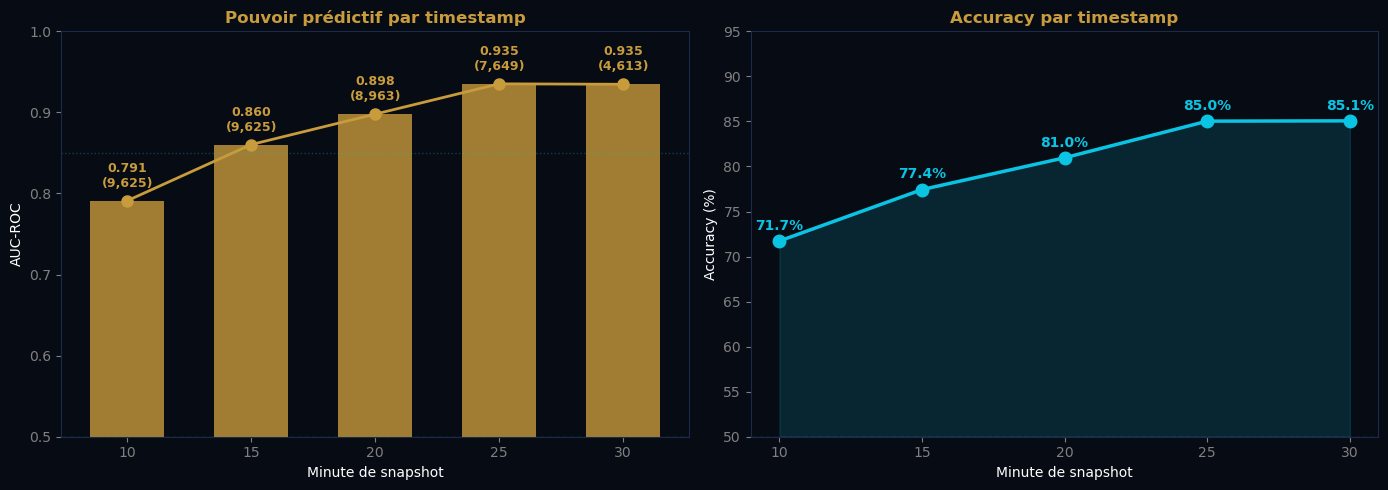

Figure 4 — Performances par timestamp


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

# AUC par minute
ax = axes[0]; ax.set_facecolor(BG)
minutes = SNAPSHOT_MINUTES
aucs = []
n_games = []
for m in minutes:
    sub = df[df['game_time_minutes'] == m]
    p = model.predict_proba(sub[FEATURE_COLS])[:, 1]
    aucs.append(roc_auc_score(sub[TARGET_COL], p))
    n_games.append(len(sub))

bars = ax.bar(minutes, aucs, color=GOLD, edgecolor='none', width=3, alpha=0.8)
ax.plot(minutes, aucs, 'o-', color=GOLD, lw=2, markersize=8, zorder=5)
ax.axhline(0.5, color='white', alpha=0.2, linestyle='--', lw=1, label='Aléatoire')
ax.axhline(0.85, color=BLUE, alpha=0.3, linestyle=':', lw=1)
for m, auc, n in zip(minutes, aucs, n_games):
    ax.annotate(f'{auc:.3f}\n({n:,})', (m, auc), textcoords='offset points',
                xytext=(0, 10), ha='center', color=GOLD, fontsize=9, fontweight='bold')
ax.set_xlabel('Minute de snapshot', color='white')
ax.set_ylabel('AUC-ROC', color='white')
ax.set_title('Pouvoir prédictif par timestamp', color=GOLD, fontweight='bold')
ax.set_ylim(0.5, 1.0); ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

# Accuracy par minute
ax = axes[1]; ax.set_facecolor(BG)
accs = []
for m in minutes:
    sub = df[df['game_time_minutes'] == m]
    p = model.predict(sub[FEATURE_COLS])
    accs.append(accuracy_score(sub[TARGET_COL], p))

ax.plot(minutes, [a * 100 for a in accs], 'o-', color=BLUE, lw=2.5, markersize=9)
ax.fill_between(minutes, 50, [a*100 for a in accs], alpha=0.15, color=BLUE)
ax.axhline(50, color='white', alpha=0.2, linestyle='--', lw=1, label='Baseline (50%)')
for m, acc in zip(minutes, accs):
    ax.annotate(f'{acc*100:.1f}%', (m, acc*100), textcoords='offset points',
                xytext=(0, 8), ha='center', color=BLUE, fontsize=10, fontweight='bold')
ax.set_xlabel('Minute de snapshot', color='white')
ax.set_ylabel('Accuracy (%)', color='white')
ax.set_title('Accuracy par timestamp', color=GOLD, fontweight='bold')
ax.set_ylim(50, 95); ax.tick_params(colors='gray')
ax.set_xticks(minutes)
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'story_performance_by_time.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 — Performances par timestamp')

---
## 6. Ce que le modèle a appris — SHAP

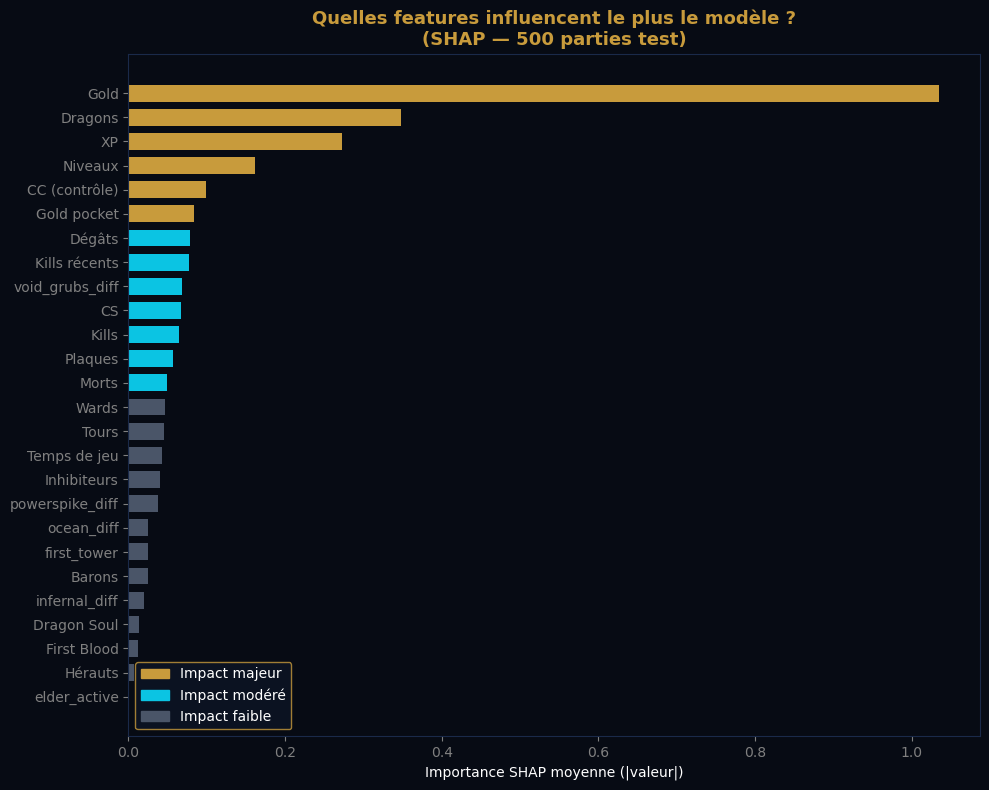

Figure 5 — SHAP feature importance


In [6]:
explainer = shap.TreeExplainer(base_xgb)
X_sample = X_test.sample(500, random_state=42)
shap_vals = explainer.shap_values(X_sample)

labels_fr = {
    'kills_diff': 'Kills', 'deaths_diff': 'Morts', 'cs_diff': 'CS', 'gold_diff': 'Gold',
    'level_diff': 'Niveaux', 'towers_diff': 'Tours', 'dragons_diff': 'Dragons',
    'heralds_diff': 'Hérauts', 'barons_diff': 'Barons', 'kills_last_3min': 'Kills récents',
    'game_time_minutes': 'Temps de jeu', 'wards_diff': 'Wards', 'inhibitors_diff': 'Inhibiteurs',
    'damage_diff': 'Dégâts', 'first_blood': 'First Blood', 'xp_diff': 'XP',
    'plates_diff': 'Plaques', 'current_gold_diff': 'Gold pocket', 'dragon_soul': 'Dragon Soul',
    'cc_diff': 'CC (contrôle)',
}

# Feature importance SHAP (mean |SHAP|)
shap_importance = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8), facecolor=BG)
ax.set_facecolor(BG)

colors = [GOLD if v >= shap_importance.quantile(0.8) else BLUE if v >= shap_importance.quantile(0.5) else '#4a5568'
          for v in shap_importance.values]

bars = ax.barh([labels_fr.get(f, f) for f in shap_importance.index],
               shap_importance.values, color=colors, edgecolor='none', height=0.7)

ax.set_xlabel('Importance SHAP moyenne (|valeur|)', color='white')
ax.set_title('Quelles features influencent le plus le modèle ?\n(SHAP — 500 parties test)', color=GOLD, fontsize=13, fontweight='bold')
ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

legend_elements = [
    mpatches.Patch(color=GOLD, label='Impact majeur'),
    mpatches.Patch(color=BLUE, label='Impact modéré'),
    mpatches.Patch(color='#4a5568', label='Impact faible'),
]
ax.legend(handles=legend_elements, facecolor=CARD, edgecolor=GOLD)

plt.tight_layout()
plt.savefig(DOCS_DIR / 'story_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 5 — SHAP feature importance')

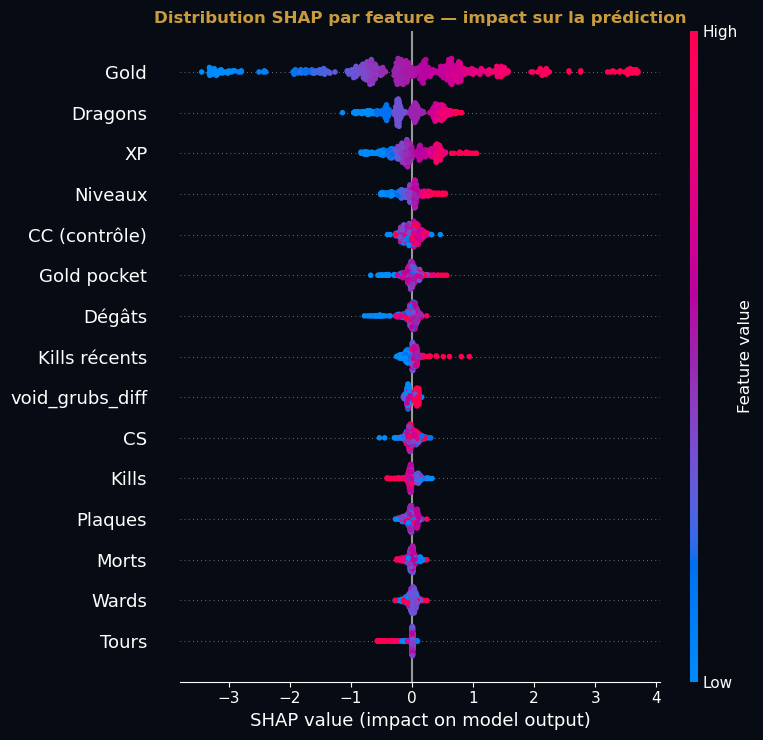

Figure 6 — SHAP beeswarm


In [7]:
# SHAP beeswarm (distribution)
fig = plt.figure(figsize=(12, 8), facecolor=BG)
ax = plt.gca(); ax.set_facecolor(BG)

shap.summary_plot(
    shap_vals, X_sample,
    feature_names=[labels_fr.get(f, f) for f in FEATURE_COLS],
    plot_type='dot',
    color_bar=True,
    show=False,
    max_display=15,
)

plt.gcf().set_facecolor(BG)
plt.gca().set_facecolor(BG)
plt.gca().tick_params(colors='white')
plt.title('Distribution SHAP par feature — impact sur la prédiction', color=GOLD, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DOCS_DIR / 'story_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 6 — SHAP beeswarm')

---
## 7. Validation — Est-ce qu'on surestime ?

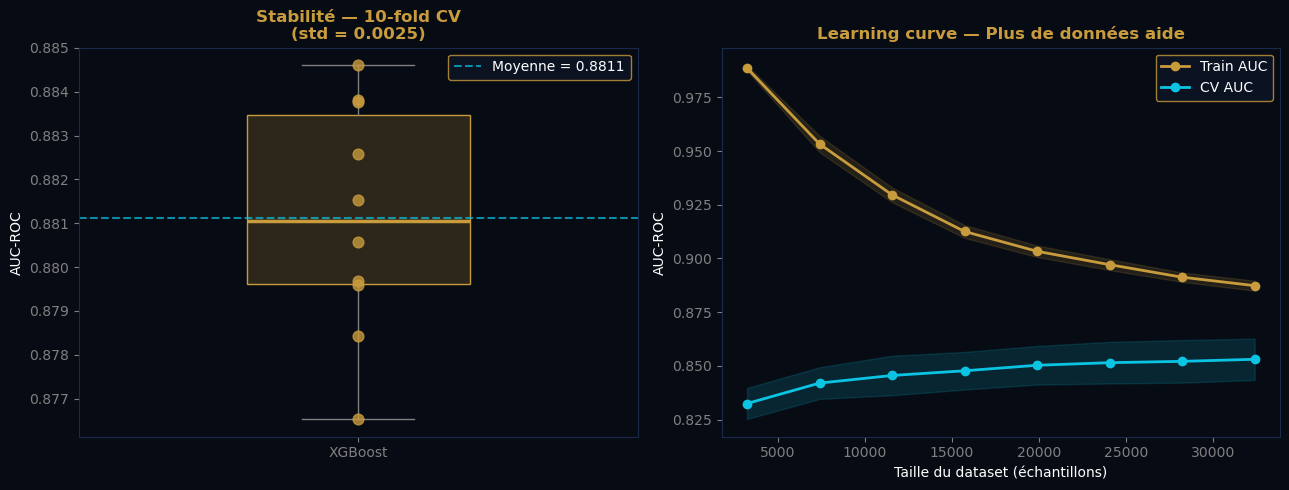

Figure 7 — Validation : AUC moyen 10-fold = 0.8811 ± 0.0025


In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# On teste sur chaque fold — vérification que le modèle ne surfit pas
fold_aucs = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    X_f, y_f = X.iloc[test_idx], y.iloc[test_idx]
    p = model.predict_proba(X_f)[:, 1]
    fold_aucs.append(roc_auc_score(y_f, p))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# Box plot des folds
ax = axes[0]; ax.set_facecolor(BG)
bp = ax.boxplot(fold_aucs, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor=GOLD+'33', edgecolor=GOLD),
                medianprops=dict(color=GOLD, lw=2.5),
                whiskerprops=dict(color='gray'), capprops=dict(color='gray'),
                flierprops=dict(marker='o', color=GOLD, alpha=0.7))
ax.scatter([1]*len(fold_aucs), fold_aucs, color=GOLD, alpha=0.8, zorder=5, s=60)
ax.axhline(np.mean(fold_aucs), color=BLUE, linestyle='--', lw=1.5, alpha=0.7,
           label=f'Moyenne = {np.mean(fold_aucs):.4f}')
ax.set_ylabel('AUC-ROC', color='white')
ax.set_title(f'Stabilité — 10-fold CV\n(std = {np.std(fold_aucs):.4f})', color=GOLD, fontweight='bold')
ax.legend(facecolor=CARD, edgecolor=GOLD); ax.tick_params(colors='gray')
ax.set_xticklabels(['XGBoost'])
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

# Learning curve
ax = axes[1]; ax.set_facecolor(BG)
from sklearn.model_selection import learning_curve
train_sizes = np.linspace(0.1, 1.0, 8)
ts, train_scores, test_scores = learning_curve(
    base_xgb, X, y, train_sizes=train_sizes, cv=5, scoring='roc_auc', n_jobs=-1
)
ax.plot(ts, train_scores.mean(axis=1), 'o-', color=GOLD, lw=2, label='Train AUC')
ax.fill_between(ts, train_scores.mean(1)-train_scores.std(1), train_scores.mean(1)+train_scores.std(1), alpha=0.15, color=GOLD)
ax.plot(ts, test_scores.mean(axis=1), 'o-', color=BLUE, lw=2, label='CV AUC')
ax.fill_between(ts, test_scores.mean(1)-test_scores.std(1), test_scores.mean(1)+test_scores.std(1), alpha=0.15, color=BLUE)
ax.set_xlabel('Taille du dataset (échantillons)', color='white')
ax.set_ylabel('AUC-ROC', color='white')
ax.set_title('Learning curve — Plus de données aide', color=GOLD, fontweight='bold')
ax.legend(facecolor=CARD, edgecolor=GOLD); ax.tick_params(colors='gray')
for sp in ax.spines.values(): sp.set_edgecolor('#1a2a4a')

plt.tight_layout()
plt.savefig(DOCS_DIR / 'story_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure 7 — Validation : AUC moyen 10-fold = {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')

---
## 8. Résumé des performances finales

In [9]:
from sklearn.metrics import log_loss, accuracy_score

xgb_proba = model.predict_proba(X_test)[:, 1]
xgb_pred  = model.predict(X_test)

summary = pd.DataFrame({
    'Métrique': ['Dataset', 'Matchs', 'Features', 'Accuracy (test)', 'AUC-ROC (test)', 'Log-loss (test)', 'AUC moyen 10-fold'],
    'Valeur': [
        f'{len(df):,} snapshots',
        f"{df['match_id'].nunique():,} matchs (Master+ EUW, Diamond, Platinum, Gold)",
        f'{len(FEATURE_COLS)} features (v3 — combat, économie, objectifs, vision, momentum)',
        f'{accuracy_score(y_test, xgb_pred):.1%}',
        f'{roc_auc_score(y_test, xgb_proba):.4f}',
        f'{log_loss(y_test, xgb_proba):.4f}',
        f'{np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}',
    ]
})
print(summary.to_string(index=False))

         Métrique                                                           Valeur
          Dataset                                                 40,475 snapshots
           Matchs              9,625 matchs (Master+ EUW, Diamond, Platinum, Gold)
         Features 26 features (v3 — combat, économie, objectifs, vision, momentum)
  Accuracy (test)                                                            77.2%
   AUC-ROC (test)                                                           0.8561
  Log-loss (test)                                                           0.4744
AUC moyen 10-fold                                                  0.8811 ± 0.0025


---
## 9. Limites et perspectives

### Limites actuelles
- **Biais EUW** : les parties Master+ EUW ont un style de jeu particulier (early game agressif). Le modèle est moins précis sur les serveurs coréen ou chinois.
- **Snapshots fixes** : on prédit à 10/15/20/25/30 min. On rate les retournements de situation entre ces minutes.
- **Pas de composition** : on ne tient pas compte des champions (certains sont plus forts en fin de partie).
- **Pas de stats individuelles normalisées** : notre blame scoring est heuristique, pas ML.

### Perspectives
- Ajouter les compositions de champions (encoder par tier list + synergie)
- Prédiction en temps réel (toutes les 10 secondes) avec l'API Live Client
- Entraîner un modèle spécifique par elo
- Intégrer les données de draft (bans/picks) pour prédire avant même le début

---

**Pipeline complet :**
```
Riot API (5 301 matchs Master+/Diamond/Plat/Gold) 
  → pull_matches.py (timelines brutes JSON)
  → parse_timelines.py (20 features × 5 timestamps = 21 846 snapshots)
  → train.py --tune (RandomizedSearchCV 40 iter, 5-fold CV)
  → XGBoost (792 arbres) + Platt calibration
  → FastAPI + SHAP → Next.js frontend
```